## Credit card fraud detection

In [1]:
!pip install numpy pandas

import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv("creditcard.csv")
print("Shape ",df.shape)
print("First 5 rows ",df.head())
print("Fraud ",df["Class"].value_counts())

Shape  (284807, 31)
First 5 rows     Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

In [3]:
X = df.drop('Class', axis=1)
y = df['Class']

print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [4]:
from sklearn.model_selection import train_test_split

### Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_Train ",X_train.shape)
print("X_Test ",X_test.shape)
print("y_Train ",y_train.shape)
print("y_Test ",y_test.shape)

X_Train  (227845, 30)
X_Test  (56962, 30)
y_Train  (227845,)
y_Test  (56962,)


In [6]:
# !pip install scikit-learn

from sklearn.preprocessing import StandardScaler

In [7]:
ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

print(X_train_scaled)
print(X_test_scaled)

[[ 1.41158751  0.99337908 -0.45603659 ...  0.19191152 -0.09910576
  -0.32249376]
 [ 0.62314085  1.03850725 -0.02934912 ...  0.00639701 -0.21152423
  -0.33976388]
 [-1.13068022 -0.50676613  0.36606499 ...  0.09413695  0.56642647
   0.34669349]
 ...
 [-1.25471074  0.54569899  0.04401572 ...  0.07676455  0.07564817
  -0.17053266]
 [-1.48398822  0.65325241  0.18256566 ... -0.14759091 -0.0184768
  -0.34813969]
 [-1.39061787 -0.30573748  0.47027277 ...  0.93509494  0.63073809
  -0.32380996]]
[[ 1.3871815  -0.34471083  0.85416023 ...  1.31850867  0.89058207
  -0.25995439]
 [-1.58013819 -1.44498471 -1.67648235 ...  0.27380388 -1.56632492
  -0.30442595]
 [-0.13812017 -1.82615312  1.40617205 ...  1.36437772  1.55873319
  -0.04828573]
 ...
 [ 1.49899849 -0.53525491  0.41575818 ...  0.04301426  0.44344588
  -0.28631824]
 [ 1.45096562  1.10222743 -0.65718284 ... -0.00616097 -0.17410048
  -0.27211925]
 [-0.92286066  0.62649961 -0.36552499 ...  0.06140638  0.1529954
  -0.11277946]]


In [8]:
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

^C


In [ ]:
# SMOTE on training data only — AFTER split and scaling
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)


print(y_train_res.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# train model on balanced data
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay
)

In [ ]:
y_pred      = rf.predict(X_test_scaled)
y_pred_prob = rf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_prob), 4))
print("PR-AUC :", round(average_precision_score(y_test, y_pred_prob), 4))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9685
PR-AUC : 0.8723


In [ ]:
!pip install matplotlib

import matplotlib.pyplot as plt

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 935.5 kB/s eta 0:00:09
  

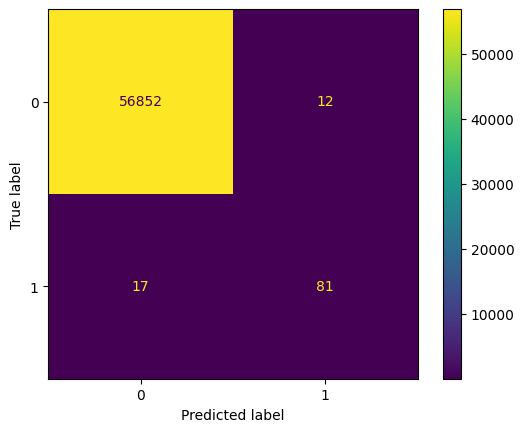

In [ ]:
import os
os.makedirs('images', exist_ok=True)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.savefig('images/confusion_matrix.png', dpi=150)
plt.show()

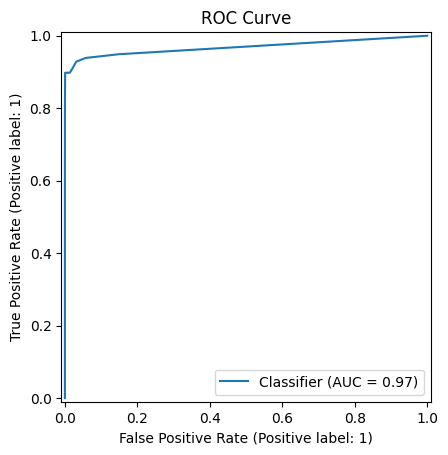

In [ ]:
RocCurveDisplay.from_predictions(y_test,y_pred_prob)
plt.title('ROC Curve')
plt.savefig('images/roc_curve.png', dpi=150)
plt.show()

In [ ]:
!pip install shap

import shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 684.0 kB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 934.2 kB/s eta 0:00:41
    --------------------------------------- 0.8/38.1 MB 1.1 MB/s eta 0:00:35
   - -------------------------------------- 1.0/38.1 MB 1.1 MB/s eta 0:00:35
   - -------------------------------------- 1.3/38.1 MB 1.0 MB/s eta 0:00:36
   - -------------------------------------- 1.6/38.1 MB 1.0 MB/s eta 0:00:36
   - -------------------------------

d:\Desktop\Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_scaled[:500])

print(explainer)
print(shap_values)


[[[ 8.21697919e-03 -8.21697919e-03]
  [ 3.24524593e-03 -3.24524593e-03]
  [ 1.61879593e-03 -1.61879593e-03]
  ...
  [-5.90670238e-04  5.90670238e-04]
  [ 6.15226363e-04 -6.15226363e-04]
  [ 4.83339357e-03 -4.83339357e-03]]

 [[ 7.81307553e-03 -7.81307553e-03]
  [ 3.39363860e-03 -3.39363860e-03]
  [ 1.10293012e-02 -1.10293012e-02]
  ...
  [ 3.08826431e-03 -3.08826431e-03]
  [ 9.25274441e-03 -9.25274441e-03]
  [ 4.01992182e-03 -4.01992182e-03]]

 [[ 1.87656130e-03 -1.87656130e-03]
  [ 7.75198280e-03 -7.75198280e-03]
  [ 3.73988839e-03 -3.73988839e-03]
  ...
  [ 1.65118890e-04 -1.65118890e-04]
  [ 2.43984400e-04 -2.43984400e-04]
  [ 3.81895725e-03 -3.81895725e-03]]

 ...

 [[ 5.88832160e-03 -5.88832160e-03]
  [ 1.30033747e-03 -1.30033747e-03]
  [ 1.32675973e-02 -1.32675973e-02]
  ...
  [ 1.71141004e-03 -1.71141004e-03]
  [ 1.00929387e-03 -1.00929387e-03]
  [ 2.76605798e-03 -2.76605798e-03]]

 [[-6.61511857e-04  6.61511857e-04]
  [ 3.73961573e-03 -3.73961573e-03]
  [ 8.70690050e-03 -8.7069

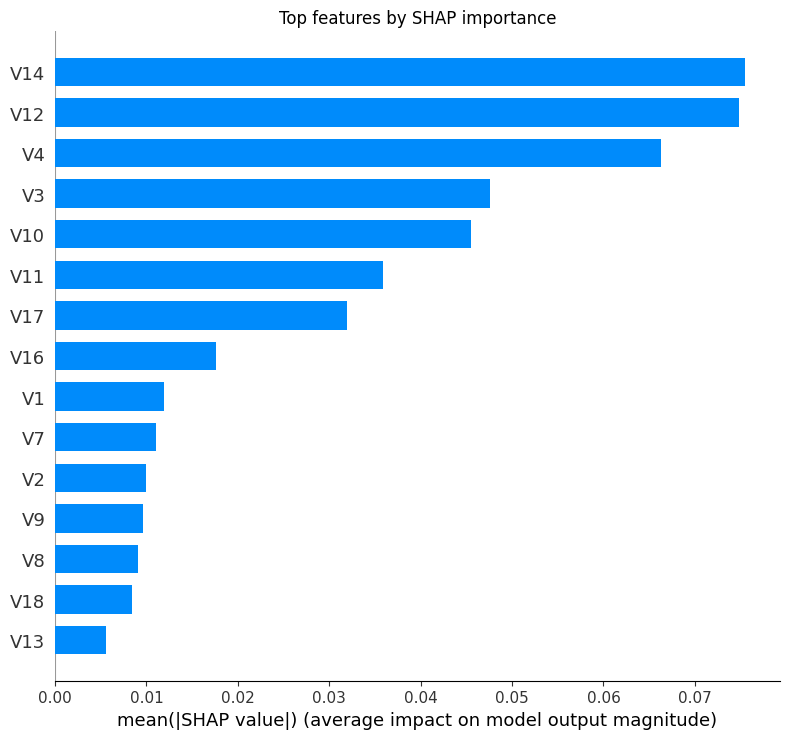

In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_scaled[:500],
    plot_type="bar",
    show=False,
    max_display=15,
    feature_names=list(X.columns)
)
plt.title('Top features by SHAP importance')
plt.tight_layout()
plt.savefig('images/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

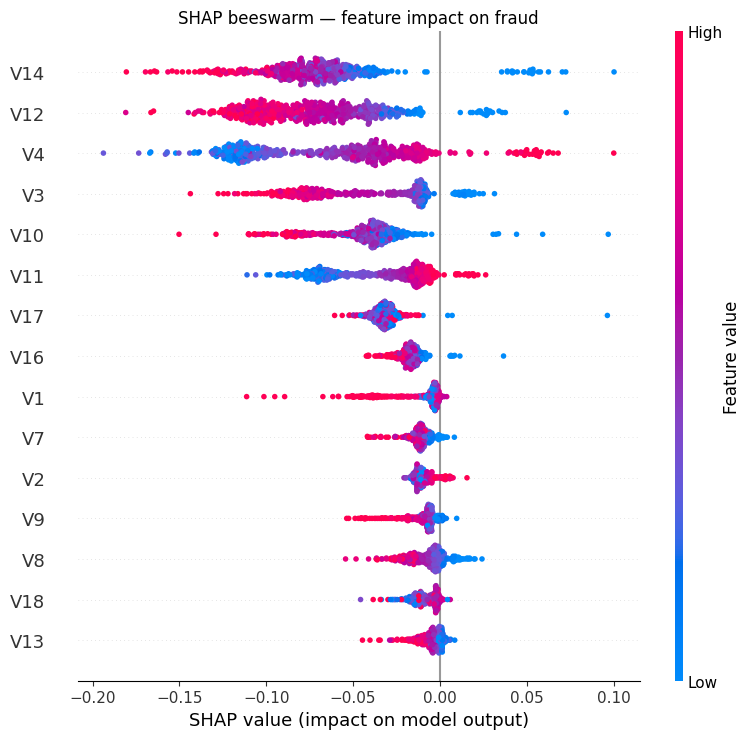

In [ ]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_scaled[:500],
    show=False,
    max_display=15,
    feature_names=list(X.columns)
)
plt.title('SHAP beeswarm — feature impact on fraud')
plt.tight_layout()
plt.savefig('images/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

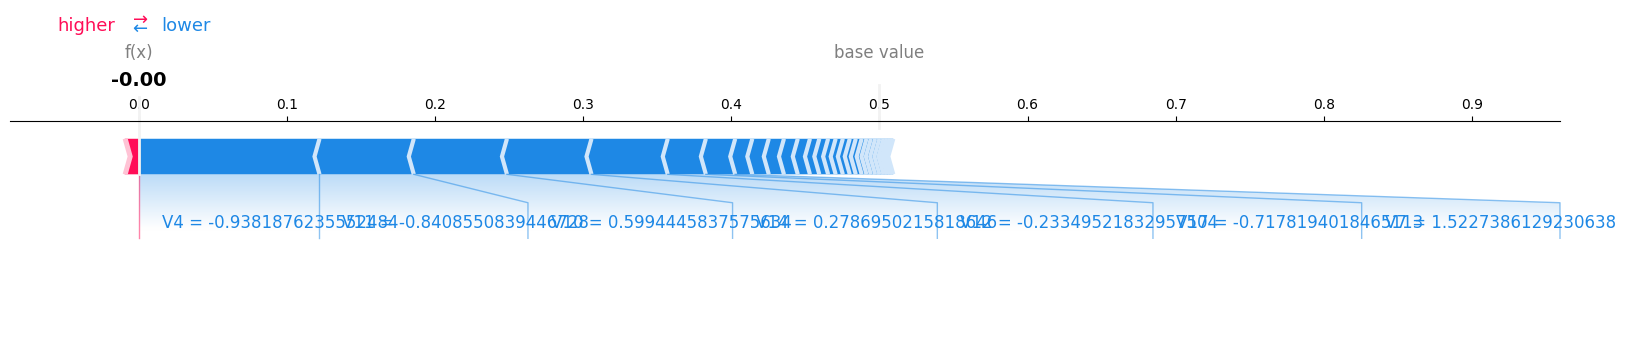

In [ ]:
fraud_positions = [i for i, val in enumerate(y_test) if val == 1]

shap.force_plot(
    explainer.expected_value[1],
    shap_values[0, :, 1],
    X_test_scaled[0],
    feature_names=list(X.columns),
    matplotlib=True,
    show=False
)
plt.savefig('images/shap_local.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
shap_values = explainer.shap_values(X_test_scaled[:2000])

y_test_list = list(y_test)
fraud_in_2000 = [i for i in range(2000) if y_test_list[i] == 1]
print("Fraud positions within first 2000:", fraud_in_2000)

Fraud positions within first 2000: [840, 1146]


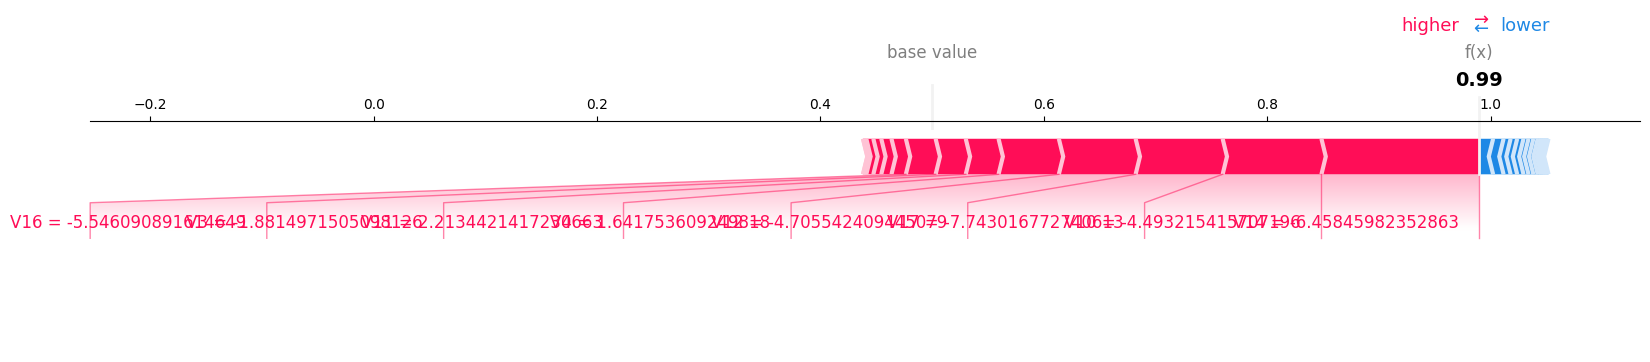

In [ ]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[840, :, 1],
    X_test_scaled[840],
    feature_names=list(X.columns),
    matplotlib=True,
    show=False
)
plt.savefig('images/shap_local.png', dpi=150, bbox_inches='tight')
plt.show()